# Ocean Data Exploration
Inspect raw NetCDF datasets and harmonized pipeline outputs.

In [1]:
from pathlib import Path
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


plt.rcParams['figure.figsize'] = (10,5)
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT/'data'
RAW_ONC_DIR = DATA_DIR/'raw'/'onc'
RAW_NOAA_DIR = DATA_DIR/'raw'/'noaa'
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\ngota\OneDrive\Desktop\SPRING 2026\ECE 591 Project\ocean-ml-rag-spark-complete


In [ ]:
def list_nc(path):
    return list(path.glob('*.nc'))

onc_files = list_nc(RAW_ONC_DIR)
noaa_files = list_nc(RAW_NOAA_DIR)
print('ONC files:', onc_files)
print('NOAA files:', noaa_files)

ONC files: [WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/onc/onc_oxygen.nc'), WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/onc/onc_salinity.nc'), WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/onc/onc_temperature.nc')]
NOAA files: [WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/noaa/noaa_pressure.nc'), WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/noaa/noaa_sst.nc'), WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/noaa/noaa_wind.nc')]


In [ ]:
files = onc_files + noaa_files
if not files:
    raise Exception('No NetCDF files found')

sample = files[0]
sample

WindowsPath('C:/Users/ngota/OneDrive/Desktop/SPRING 2026/ECE 591 Project/ocean-ml-rag-spark-complete/data/raw/onc/onc_oxygen.nc')

In [4]:
ds = xr.open_dataset(sample)
ds

<xarray.Dataset> Size: 114MB
Dimensions:           (row: 3552866)
Dimensions without coordinates: row
Data variables:
    time              (row) datetime64[ns] 28MB ...
    oxygen_corrected  (row) float64 28MB ...
    latitude          (row) float64 28MB ...
    longitude         (row) float64 28MB ...
Attributes: (12/38)
    cdm_data_type:                 TimeSeries
    cdm_timeseries_variables:      timeseries_id,longitude,depth,latitude
    contributor_name:              Ocean Networks Canada Society,Ocean Networ...
    contributor_role:              Custodian,Owner,Publisher
    Conventions:                   COARDS, CF-1.6, ACDD-1.3
    device_id:                     24003
    ...                            ...
    summary:                       abstract: English = The Sea-Bird SBE 63 Di...
    time_coverage_end:             2021-06-15T16:12:05.993Z
    time_coverage_resolution:      PT1S
    time_coverage_start:           2021-05-04T23:22:29.722Z
    title:                         Baynes Sound Oxygen Sensor Deployed 2019-1...
    Westernmost_Easting:           -124.769333

In [5]:
print('Variables:')
for v in ds.data_vars:
    print(v)

print('\nCoordinates:')
for c in ds.coords:
    print(c)

Variables:
time
oxygen_corrected
latitude
longitude

Coordinates:


In [6]:
var = list(ds.data_vars)[0]
df = ds[[var]].to_dataframe().reset_index()
df.head()

,row,time
0,0,2021-05-04 23:22:29.721999872
1,1,2021-05-04 23:22:31.749000192
2,2,2021-05-04 23:22:32.772000000
3,3,2021-05-04 23:22:33.796000000
4,4,2021-05-04 23:22:34.818000128


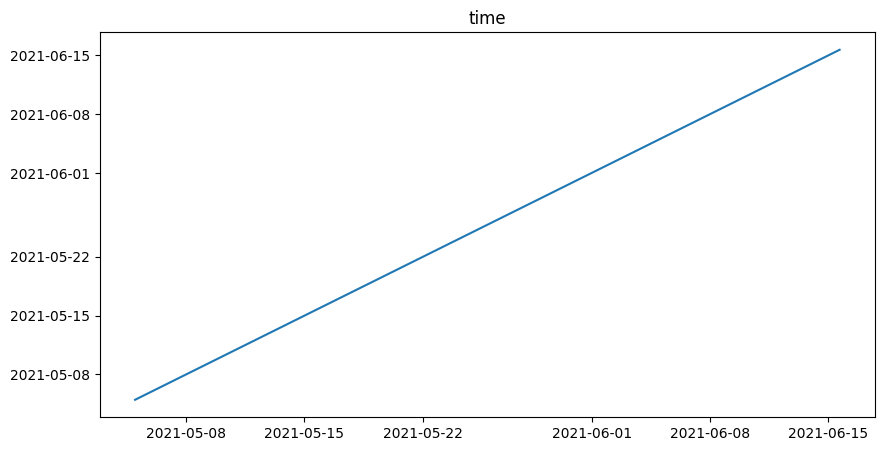

In [ ]:
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time')
    plt.plot(df['time'], df[var])
    plt.title(var)
    plt.show()